# Using Numpy Only

## 0. Libraries

In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

## 1. Import `make_moons` Dataset

The `make_moons` dataset is a synthetic 2D binary classification dataset generated by scikit-learn consisting of two interlocking, crescent-shaped clusters.

- Input Features (X): A 2D array of coordinates ($x1$, $x2$) representing a point positions on a Cartesian plane.
- Target Labels (y): A 1D array of binary values (0 for the upper crescent, 1 for the lower crescent)

In [2]:
X, y = datasets.make_moons(n_samples=200, noise=0.2, random_state=42)

print(X.shape)
print(y.shape)

(200, 2)
(200,)


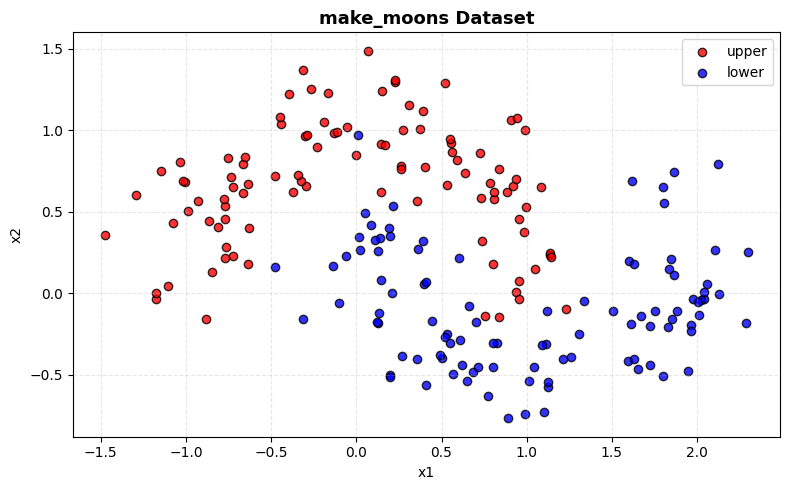

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(X[y==0, 0], X[y==0, 1], label='upper', color='r', edgecolors='k', alpha = 0.8)
plt.scatter(X[y==1, 0], X[y==1, 1], label='lower', color='b', edgecolors='k', alpha = 0.8)

plt.title('make_moons Dataset', fontsize=13, fontweight='bold')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

## 2. Initialize Weights

In [15]:
def init_weights(X, random_seed=42):
    np.random.seed(random_seed)

    fan_in, fan_out = X.shape[1], 1

    W1 = np.random.randn(fan_in, 4) * 0.01
    b1 = np.zeros(4)
    W2 = np.random.randn(4, fan_out) * 0.01
    b2 = np.zeros(1)

    return W1, b1, W2, b2

## 3. Forward Pass

In [16]:
def forward_pass(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1) # relu
    z2 = a1 @ W2 + b2
    a2 = 1 / (1 + np.exp(-z2)) # sigmoid

    return z1, a1, z2, a2

## 4. Loss Function

In [17]:
def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    y_pred = np.clip(y_pred, eps, 1- eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return loss

## 5. Backward Pass

In [18]:
def backward_pass(X, y, W1, b1, W2, b2):
    z1, a1, _, a2 = forward_pass(X, W1, b1, W2, b2)

    dz2 = (a2 - y) / X.shape[0]
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0)
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)

    return a2, dW1, db1, dW2, db2

## 6. Parameter Update

In [19]:
def parameter_update(X, y, W1, b1, W2, b2, lr):
    a2, dW1, db1, dW2, db2 = backward_pass(X, y, W1, b1, W2, b2)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    return a2, W1, b1, W2, b2

## 7. Train NN

In [20]:
def learn_nn(X, y, num_steps = 2000, lr = 0.1):
    W1, b1, W2, b2 = init_weights(X)

    for epoch in range(num_steps):
        a2, W1, b1, W2, b2 = parameter_update(X, y, W1, b1, W2, b2, lr)

        if epoch % 100 == 0:
            acc = np.mean((a2 > 0.5) == y)
            loss = binary_cross_entropy(y, a2)
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Acc: {acc:.2%}")

    return a2, W1, b1, W2, b2

In [54]:
y_true = y.reshape(-1, 1)

y_pred, nn_W1, nn_b1, nn_W2, nn_b2 = learn_nn(X, y_true, num_steps = 2000, lr = 0.1)

Epoch    0 | Loss: 0.6932 | Acc: 46.00%
Epoch  100 | Loss: 0.6925 | Acc: 81.50%
Epoch  200 | Loss: 0.6542 | Acc: 82.00%
Epoch  300 | Loss: 0.3816 | Acc: 83.00%
Epoch  400 | Loss: 0.3235 | Acc: 85.50%
Epoch  500 | Loss: 0.3145 | Acc: 84.50%
Epoch  600 | Loss: 0.3127 | Acc: 83.50%
Epoch  700 | Loss: 0.3121 | Acc: 83.50%
Epoch  800 | Loss: 0.3119 | Acc: 83.50%
Epoch  900 | Loss: 0.3117 | Acc: 83.50%
Epoch 1000 | Loss: 0.3116 | Acc: 83.50%
Epoch 1100 | Loss: 0.3116 | Acc: 83.50%
Epoch 1200 | Loss: 0.3115 | Acc: 83.50%
Epoch 1300 | Loss: 0.3115 | Acc: 83.50%
Epoch 1400 | Loss: 0.3115 | Acc: 83.50%
Epoch 1500 | Loss: 0.3115 | Acc: 83.50%
Epoch 1600 | Loss: 0.3114 | Acc: 83.50%
Epoch 1700 | Loss: 0.3114 | Acc: 83.50%
Epoch 1800 | Loss: 0.3114 | Acc: 83.50%
Epoch 1900 | Loss: 0.3114 | Acc: 83.50%


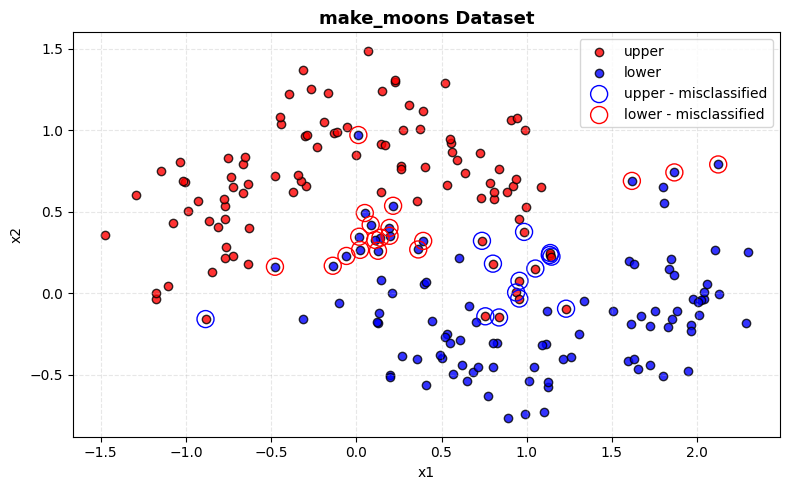

In [55]:
wrong = (y_pred.flatten() > 0.5) != y_true.flatten()

plt.figure(figsize=(8,5))
plt.scatter(X[y==0, 0], X[y==0, 1], label='upper', color='r', edgecolors='k', alpha=0.8)
plt.scatter(X[y==1, 0], X[y==1, 1], label='lower', color='b', edgecolors='k', alpha=0.8)
plt.scatter(X[wrong & (y==0), 0], X[wrong & (y==0), 1], facecolors='none', edgecolors='b', s=150, linewidths=1, label='upper - misclassified')
plt.scatter(X[wrong & (y==1), 0], X[wrong & (y==1), 1], facecolors='none', edgecolors='r', s=150, linewidths=1, label='lower - misclassified')

plt.title('make_moons Dataset', fontsize=13, fontweight='bold')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Using PyTorch

## 0. Libraries

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

## 1. Transform Data format to tensor

In [ ]:
X_t = torch.tensor(X, dtype=torch.float32)
y_true_t = torch.tensor(y_true, dtype=torch.float32)

print(X_t.shape)
print(y_true_t.shape)

torch.Size([200, 2])
torch.Size([200, 1])


## 2. Define Neural Network

In [51]:
class NN_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

nn_1 = NN_PyTorch()

# 3. Loss function

In [56]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(nn_1.parameters(), lr = 0.1)

## 4. Train NN

In [57]:
for epoch in range(2000):
    optimizer.zero_grad()

    y_pred_t = nn_1(X_t)
    loss = criterion(y_pred_t, y_true_t)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 99:    # print every 100 mini-batches
        with torch.no_grad():
            acc = ((torch.sigmoid(y_pred_t) > 0.5).float() == y_true_t).float().mean()
        print(f'Epoch {epoch + 1:4d} | Loss: {loss:.4f} | Acc: {acc:.2%}')
        

Epoch  100 | Loss: 0.4610 | Acc: 81.00%
Epoch  200 | Loss: 0.3781 | Acc: 85.00%
Epoch  300 | Loss: 0.3425 | Acc: 85.50%
Epoch  400 | Loss: 0.3257 | Acc: 84.50%
Epoch  500 | Loss: 0.3159 | Acc: 84.50%
Epoch  600 | Loss: 0.3102 | Acc: 84.50%
Epoch  700 | Loss: 0.3061 | Acc: 85.50%
Epoch  800 | Loss: 0.3028 | Acc: 85.50%
Epoch  900 | Loss: 0.3000 | Acc: 85.50%
Epoch 1000 | Loss: 0.2974 | Acc: 85.50%
Epoch 1100 | Loss: 0.2952 | Acc: 85.50%
Epoch 1200 | Loss: 0.2931 | Acc: 86.00%
Epoch 1300 | Loss: 0.2911 | Acc: 86.00%
Epoch 1400 | Loss: 0.2893 | Acc: 86.00%
Epoch 1500 | Loss: 0.2877 | Acc: 86.00%
Epoch 1600 | Loss: 0.2862 | Acc: 86.00%
Epoch 1700 | Loss: 0.2847 | Acc: 86.00%
Epoch 1800 | Loss: 0.2832 | Acc: 86.00%
Epoch 1900 | Loss: 0.2819 | Acc: 86.00%
Epoch 2000 | Loss: 0.2805 | Acc: 86.00%


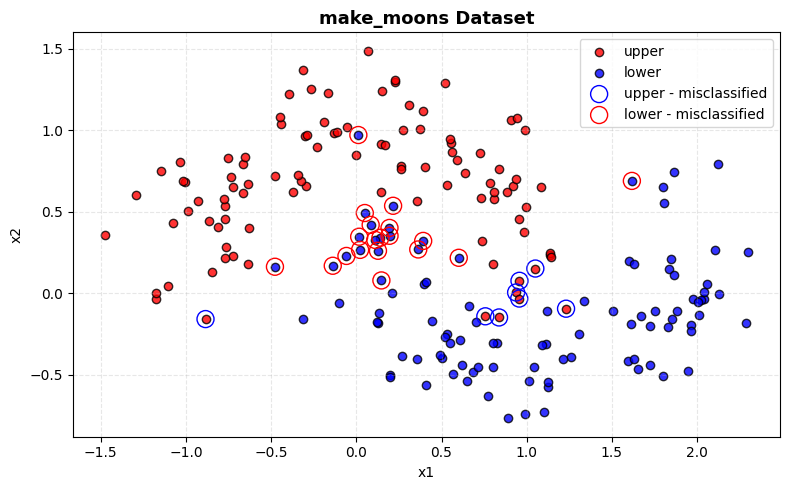

In [59]:
with torch.no_grad():
    y_pred2 = y_pred_t.flatten().numpy()

wrong2 = (y_pred2 > 0.5) != y 

plt.figure(figsize=(8,5))
plt.scatter(X[y==0, 0], X[y==0, 1], label='upper', color='r', edgecolors='k', alpha=0.8)
plt.scatter(X[y==1, 0], X[y==1, 1], label='lower', color='b', edgecolors='k', alpha=0.8)
plt.scatter(X[wrong2 & (y==0), 0], X[wrong2 & (y==0), 1], facecolors='none', edgecolors='b', s=150, linewidths=1, label='upper - misclassified')
plt.scatter(X[wrong2 & (y==1), 0], X[wrong2 & (y==1), 1], facecolors='none', edgecolors='r', s=150, linewidths=1, label='lower - misclassified')

plt.title('make_moons Dataset', fontsize=13, fontweight='bold')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()